# Predicting Stellar Class — アンサンブルモデル

天体データから `GALAXY` / `QSO` / `STAR` の3クラスを予測する。

- **評価指標**: Balanced Accuracy
- **モデル**: LightGBM + XGBoost + CatBoost のアンサンブル(確率平均)
- **不均衡対策**: クラスバランス化したサンプル重みで学習
- **検証**: StratifiedKFold 5-fold のOOF評価

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

SEED = 42
N_FOLDS = 5

train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")
sample_sub = pd.read_csv("data/sample_submission.csv")

print(train.shape, test.shape)
train.head()

(577347, 12) (247435, 11)


,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


## 1. 簡単なEDA

クラス分布と、判別に効きそうな `redshift` の分布を確認する。

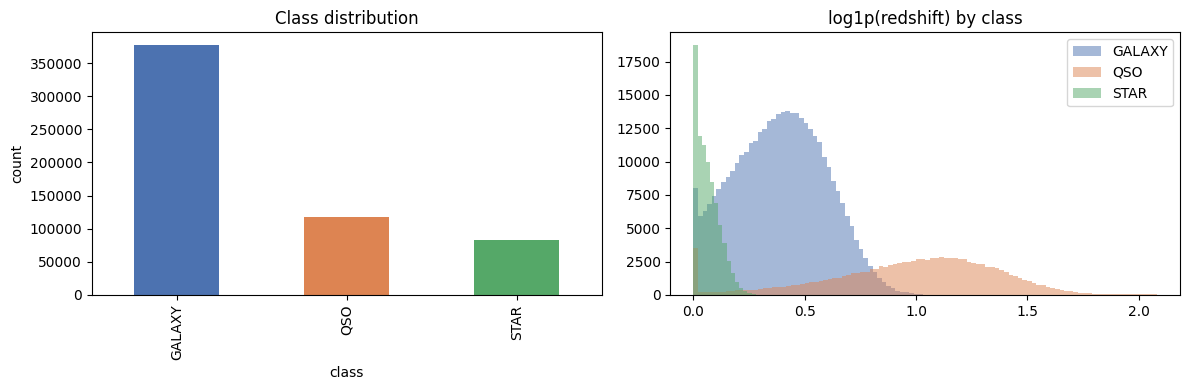

           count      mean       std       min       25%       50%       75%  \
class                                                                          
GALAXY  377480.0  0.509026  0.309139 -0.009934  0.267017  0.481960  0.715023   
QSO     117143.0  1.875641  1.069731  0.000100  1.131805  1.798886  2.506401   
STAR     82724.0  0.068115  0.064476 -0.009970  0.021884  0.056492  0.102069   

             max  
class             
GALAXY  6.860273  
QSO     7.010780  
STAR    5.445217  


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train["class"].value_counts().plot.bar(ax=axes[0], color=["#4c72b0", "#dd8452", "#55a868"])
axes[0].set_title("Class distribution")
axes[0].set_ylabel("count")

for cls, color in zip(["GALAXY", "QSO", "STAR"], ["#4c72b0", "#dd8452", "#55a868"]):
    subset = train.loc[train["class"] == cls, "redshift"]
    axes[1].hist(np.log1p(subset.clip(lower=0)), bins=100, alpha=0.5, label=cls, color=color)
axes[1].set_title("log1p(redshift) by class")
axes[1].legend()

plt.tight_layout()
plt.show()

print(train.groupby("class")["redshift"].describe())

## 2. 特徴量エンジニアリング

- **色指数 (color index)**: 隣接バンドの等級差(`u-g`, `g-r`, `r-i`, `i-z`)は天体分類の定番特徴量
- 広いバンド間の差(`u-r`, `g-i`, `u-z`)も追加
- `redshift` は分布が裾広がりなので `log1p` 変換版も追加
- カテゴリ列(`spectral_type`, `galaxy_population`)はラベルエンコードし、LightGBM / CatBoost にはカテゴリとして渡す
- `alpha` / `delta`(天球座標)は本来クラスと無関係のはずだが、念のため残してモデルに判断させる

In [3]:
CAT_COLS = ["spectral_type", "galaxy_population"]


def build_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # 色指数(隣接バンド)
    out["u_g"] = out["u"] - out["g"]
    out["g_r"] = out["g"] - out["r"]
    out["r_i"] = out["r"] - out["i"]
    out["i_z"] = out["i"] - out["z"]
    # 広いバンド間
    out["u_r"] = out["u"] - out["r"]
    out["g_i"] = out["g"] - out["i"]
    out["u_z"] = out["u"] - out["z"]

    out["redshift_log1p"] = np.log1p(out["redshift"].clip(lower=0))

    return out


# カテゴリ列はtrain/test共通のエンコーダで数値化
cat_encoders = {}
for col in CAT_COLS:
    le = LabelEncoder()
    le.fit(pd.concat([train[col], test[col]]))
    cat_encoders[col] = le

train_fe = build_features(train)
test_fe = build_features(test)
for col, le in cat_encoders.items():
    train_fe[col] = le.transform(train_fe[col])
    test_fe[col] = le.transform(test_fe[col])

FEATURES = [c for c in train_fe.columns if c not in ("id", "class")]

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(train_fe["class"])
X = train_fe[FEATURES]
X_test = test_fe[FEATURES]

# balanced accuracy向けにクラスバランス化した重み
sample_weight = compute_sample_weight("balanced", y)

print("features:", FEATURES)
print("classes:", list(target_encoder.classes_))

features: ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'spectral_type', 'galaxy_population', 'u_g', 'g_r', 'r_i', 'i_z', 'u_r', 'g_i', 'u_z', 'redshift_log1p']
classes: ['GALAXY', 'QSO', 'STAR']


## 3. 学習(5-fold CV + 3モデル)

各foldで LightGBM / XGBoost / CatBoost を学習し、

- OOF(out-of-fold)予測確率 → アンサンブルの検証用
- テストデータへの予測確率(fold平均) → 提出用

をそれぞれ貯める。早期終了(early stopping)で過学習を抑える。

In [4]:
from catboost import Pool

N_CLASSES = len(target_encoder.classes_)
MODEL_NAMES = ["lgbm", "xgb", "cat"]

oof = {m: np.zeros((len(X), N_CLASSES)) for m in MODEL_NAMES}
pred_test = {m: np.zeros((len(X_test), N_CLASSES)) for m in MODEL_NAMES}

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y)):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y[tr_idx], y[va_idx]
    w_tr, w_va = sample_weight[tr_idx], sample_weight[va_idx]

    # ---- LightGBM ----
    lgbm_model = lgb.LGBMClassifier(
        objective="multiclass",
        n_estimators=2000,
        learning_rate=0.05,
        num_leaves=127,
        colsample_bytree=0.8,
        subsample=0.8,
        subsample_freq=1,
        random_state=SEED,
        n_jobs=-1,
        verbosity=-1,
    )
    lgbm_model.fit(
        X_tr, y_tr,
        sample_weight=w_tr,
        eval_set=[(X_va, y_va)],
        eval_sample_weight=[w_va],
        categorical_feature=CAT_COLS,
        callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)],
    )
    oof["lgbm"][va_idx] = lgbm_model.predict_proba(X_va)
    pred_test["lgbm"] += lgbm_model.predict_proba(X_test) / N_FOLDS

    # ---- XGBoost ----
    xgb_model = xgb.XGBClassifier(
        objective="multi:softprob",
        n_estimators=2000,
        learning_rate=0.05,
        max_depth=8,
        colsample_bytree=0.8,
        subsample=0.8,
        tree_method="hist",
        early_stopping_rounds=100,
        random_state=SEED,
        n_jobs=-1,
        verbosity=0,
    )
    xgb_model.fit(
        X_tr, y_tr,
        sample_weight=w_tr,
        eval_set=[(X_va, y_va)],
        sample_weight_eval_set=[w_va],
        verbose=False,
    )
    oof["xgb"][va_idx] = xgb_model.predict_proba(X_va)
    pred_test["xgb"] += xgb_model.predict_proba(X_test) / N_FOLDS

    # ---- CatBoost ----
    cat_feature_idx = [FEATURES.index(c) for c in CAT_COLS]
    cat_model = CatBoostClassifier(
        loss_function="MultiClass",
        iterations=2000,
        learning_rate=0.08,
        depth=8,
        random_seed=SEED,
        early_stopping_rounds=100,
        verbose=0,
    )
    cat_model.fit(
        Pool(X_tr, y_tr, weight=w_tr, cat_features=cat_feature_idx),
        eval_set=Pool(X_va, y_va, weight=w_va, cat_features=cat_feature_idx),
    )
    oof["cat"][va_idx] = cat_model.predict_proba(X_va)
    pred_test["cat"] += cat_model.predict_proba(X_test) / N_FOLDS

    scores = {
        m: balanced_accuracy_score(y_va, oof[m][va_idx].argmax(axis=1))
        for m in MODEL_NAMES
    }
    print(f"fold {fold}: " + ", ".join(f"{m}={s:.5f}" for m, s in scores.items()))

for m in MODEL_NAMES:
    print(f"OOF balanced accuracy [{m}]: {balanced_accuracy_score(y, oof[m].argmax(axis=1)):.5f}")

fold 0: lgbm=0.96514, xgb=0.96452, cat=0.96395


fold 1: lgbm=0.96499, xgb=0.96435, cat=0.96373


fold 2: lgbm=0.96450, xgb=0.96406, cat=0.96340


fold 3: lgbm=0.96410, xgb=0.96374, cat=0.96297


fold 4: lgbm=0.96471, xgb=0.96410, cat=0.96315
OOF balanced accuracy [lgbm]: 0.96469
OOF balanced accuracy [xgb]: 0.96415
OOF balanced accuracy [cat]: 0.96344


## 4. アンサンブル

3モデルの予測確率を重み付き平均する。重みはOOFのbalanced accuracyが最大になる組み合わせをグリッドサーチで決める。

best weights (lgbm, xgb, cat) = (0.5, 0.4, 0.09999999999999998)
ensemble OOF balanced accuracy = 0.96488


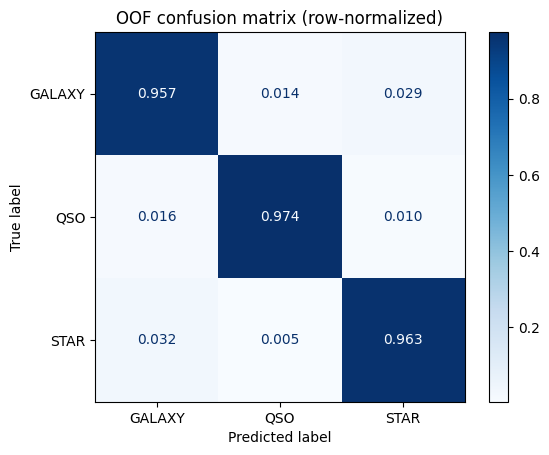

In [5]:
from itertools import product

best_weights, best_score = None, -1.0
grid = np.arange(0.0, 1.05, 0.1)
for w1, w2 in product(grid, grid):
    w3 = 1.0 - w1 - w2
    if w3 < -1e-9:
        continue
    blend = w1 * oof["lgbm"] + w2 * oof["xgb"] + max(w3, 0.0) * oof["cat"]
    score = balanced_accuracy_score(y, blend.argmax(axis=1))
    if score > best_score:
        best_score = score
        best_weights = (w1, w2, max(w3, 0.0))

print(f"best weights (lgbm, xgb, cat) = {best_weights}")
print(f"ensemble OOF balanced accuracy = {best_score:.5f}")

oof_blend = sum(w * oof[m] for w, m in zip(best_weights, MODEL_NAMES))
oof_pred = oof_blend.argmax(axis=1)

cm = confusion_matrix(y, oof_pred, normalize="true")
disp = ConfusionMatrixDisplay(cm, display_labels=target_encoder.classes_)
disp.plot(cmap="Blues", values_format=".3f")
plt.title("OOF confusion matrix (row-normalized)")
plt.show()

## 5. 提出ファイル作成

In [6]:
test_blend = sum(w * pred_test[m] for w, m in zip(best_weights, MODEL_NAMES))
test_pred = target_encoder.inverse_transform(test_blend.argmax(axis=1))

submission = pd.DataFrame({"id": test_fe["id"], "class": test_pred})
assert (submission["id"].values == sample_sub["id"].values).all()
submission.to_csv("submission.csv", index=False)

print(submission["class"].value_counts())
submission.head()

class
GALAXY    157023
QSO        51262
STAR       39150
Name: count, dtype: int64


,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,STAR
4,577351,GALAXY
